> **MTM-only re-score (Fusion_PhD-bhx7.9, 2026-10-02).** n1000 is gated on the label `MTM` of `general_analysis.mode_classification` at GA master `77e04d9` (T > 0.15, omega < 0); the 5x5 grid and the ladders keep the original tearing-parity fallback in the main analysis, and the last cells report how many of their cells are MTM under the new rule and refit the 5x5 law on them. All other cells are the original analysis; the text cells below that quote numbers are the ORIGINAL ones and are superseded by this run's printed output.


# Does the MTM parallel extent depend on anything but k_y and ŝ? (Fusion_PhD-bhx7.8)

**Question.** The extent law `θ₉₅ = 9.46 kᵧ^−0.351 ŝ^−0.527 [π]` (`Fusion_PhD-9h5`, fitted to a 5×5 (kᵧ, ŝ) GS2 scan, `Fusion_PhD-497`) sizes GFTM's basis. It assumes the extent depends on **only** kᵧ and ŝ. The existing figures never plot the extent against any other parameter. This notebook does, on every existing GS2 database where a parameter varies; **no new runs**.

**Extent.** pyrokinetics `Extent` (95 % rule, full span in units of π) of `|φ|² + |A∥|²` at the final time of each GS2 run. This is the field and definition of the law's numbers (`MTM_analysis.mtm_detect_gs2scan.harvest_one`); it is checked below by reproducing the 5×5 numbers of `results/mtm_kxscan`.

**Data** (`GK_DATA_ROOT/GS2/Runs/`):
- `KX_SCAN/NSTX_MTM/ky_shat_5x5/grid`: 5×5 (kᵧ, ŝ) grid, everything else fixed. The law's fitting data.
- `KX_SCAN/NSTX_MTM/nu_beta_ladders/{nu,beta}/{base,shat_low,ky_high}`: one-axis ladders in ν (both species together) and β at three fixed (kᵧ, ŝ). The ×1 rung is the 5×5 grid cell itself.
- `LATIN_HYPERCUBE/NSTX_MTM/beta_q_shat_ky_n1000`: 1000-point Latin hypercube (β, q, ŝ, kᵧ vary).

**Parameters** are read from each run's own deck through pyrokinetics (`Pyro`), not assumed: kᵧ, ŝ, q, β, ν, the four gradients and the Miller shape. A parameter that does not vary in a database cannot be tested there; the notebook says which.

**MTM population.** n1000: `general_analysis.mode_classification` label `MTM` (consensus of tearing parity, mode direction and χₑ/χᵢ). 5×5 and ladders: *tearing parity* (A∥ even fraction E > 0.5, `FieldLine.compute_linear_parity`) and electron direction (ω < 0), the MTM definition of `mtm_core_tail`; the strict consensus label was tried first and keeps only 6 of 25 grid cells and no ladder rung, because it demands χₑ/χᵢ > 10 and T > 0.7 on top of parity. A sensitivity cell re-does n1000 with the same tearing-parity gate. All: growth rate > 0 and `frac_edge` < 1e-2 (the 497 box gate: the extent is not truncated by the θ box). Every drop is counted.

**Advisory.** The numbers are fits to these cases. "Depends" means the 95 % interval excludes zero; the effect size over the sampled range is always given beside it.

In [1]:
import os, sys, warnings, json
from multiprocessing import Pool
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import StrMethodFormatter
from dotenv import load_dotenv
from pyrokinetics import Pyro
from pyrokinetics.diagnostics.extent import Extent
from pyrokinetics.diagnostics.field_line import FieldLine

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file() and (p / "notebooks").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from general_analysis import mode_classification as mc

warnings.filterwarnings("ignore")
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
plt.rcParams.update({"axes.titlesize": 20, "axes.labelsize": 20, "xtick.labelsize": 17, "ytick.labelsize": 17, "legend.fontsize": 15})  # the user's format (kbm_extent_filter 10546f9)
def plain_ticks(ax):
    """Log axes: fixed 1-2-5 ticks inside the limits, plain {x:g} labels, no minor ticks (kbm_extent_filter format)."""
    for axis, lim, setter in ((ax.xaxis, ax.get_xlim(), ax.set_xticks), (ax.yaxis, ax.get_ylim(), ax.set_yticks)):
        if axis.get_scale() != "log": continue
        t = [m * 10.0 ** e for e in range(int(np.floor(np.log10(lim[0]))) - 1, int(np.ceil(np.log10(lim[1]))) + 1) for m in (1, 2, 5)]
        setter([v for v in t if lim[0] <= v <= lim[1]]); axis.set_major_formatter(StrMethodFormatter("{x:g}"))
        axis.set_minor_formatter(plt.NullFormatter()); axis.set_minor_locator(plt.NullLocator())
        (ax.set_xlim if axis is ax.xaxis else ax.set_ylim)(lim)
load_dotenv(ROOT / "local.env", override=True)
runs_root = Path(os.environ["GK_DATA_ROOT"]).expanduser() / "GS2" / "Runs"
plot_dir = ROOT / "Plots" / "mtm_extent_parameters_mtm_only"
plot_dir.mkdir(parents=True, exist_ok=True)
kx = runs_root / "KX_SCAN/NSTX_MTM"
lhc = runs_root / "LATIN_HYPERCUBE/NSTX_MTM/beta_q_shat_ky_n1000"
cells = ["base", "shat_low", "ky_high"]
# database -> run directories (each holds gs2.in)
sets = {"5x5": sorted((kx / "ky_shat_5x5/grid").glob("ky*/shat*")),
        "n1000": sorted(lhc.glob("iteration_*"))}
for ladder, pat in (("nu", "electron_nu*"), ("beta", "beta*")):
    for c in cells:
        sets[f"{ladder}:{c}"] = sorted((kx / "nu_beta_ladders" / ladder / c).glob(f"ky*/shat*/{pat}"))
law_published = dict(a=-0.351, b=-0.527, envelope=9.46, margin=1.327)  # results/mtm_kxscan_widefit, Fusion_PhD-9h5
gate_edge, gate_gamma = 1e-2, 0.0
print({k: len(v) for k, v in sets.items()})

{'5x5': 25, 'n1000': 1000, 'nu:base': 8, 'nu:shat_low': 8, 'nu:ky_high': 8, 'beta:base': 4, 'beta:shat_low': 4, 'beta:ky_high': 4}


## Load

One `Pyro` per run (fields + fluxes). Per run: the extent, the mode-classification label, and every parameter the deck defines. kᵧ is converted to pyrokinetics units (ρ_ref,pyro), the unit of the law.

In [2]:
plain = lambda a: a.pint.dequantify() if hasattr(a, "pint") else a
last = lambda a: plain(a).isel(time=-1) if "time" in a.dims else plain(a)
num = lambda v: float(getattr(v, "m", v))

def one(args):
    db, d = args
    try:
        p = Pyro(gk_file=d / "gs2.in")
        p.load_gk_output(load_fields=True, load_fluxes=True, load_moments=False)
        out, ls, g = p.gk_output, p.local_species, p.local_geometry
        power = (abs(last(out["phi"])) ** 2 + abs(last(out["apar"])) ** 2).isel(kx=0, ky=0)
        out.data = out.data.assign(eigenfunctions_squared=power)
        Extent(out)
        th, w = np.asarray(power.theta), np.asarray(power)
        edge = np.trapezoid(w * (abs(th) > 0.9 * abs(th).max()), th) / np.trapezoid(w, th)
        E = float(plain(FieldLine(p).compute_linear_parity()).values.ravel()[0])
        e, i = ls["electron"], ls[[s for s in ls.names if s != "electron"][0]]
        par = dict(ky=num(p.numerics.ky.to(p.norms.pyrokinetics.rhoref ** -1)), shat=num(g.shat), q=num(g.q),
                   beta=num(p.numerics.beta), nu_e=num(e.nu), nu_i=num(i.nu), aLTe=num(e.inverse_lt), aLTi=num(i.inverse_lt),
                   aLne=num(e.inverse_ln), aLni=num(i.inverse_ln), kappa=num(g.kappa), delta=num(g.delta),
                   s_kappa=num(g.s_kappa), s_delta=num(g.s_delta), shift=num(g.shift), beta_prime=num(g.beta_prime),
                   nperiod=float(p.numerics.nperiod))
        return dict(db=db, run=d.name, extent=num(out["extent"]) / np.pi, edge=float(edge),
                    gamma=float(last(out["growth_rate"]).squeeze()), E=E, **par, **mc.indicators(p))
    except Exception as ex:
        return dict(db=db, run=str(d), err=repr(ex)[:150])

jobs = [(db, d) for db, ds in sets.items() for d in ds]
with Pool(int(os.environ.get("SLURM_CPUS_PER_TASK", 4))) as pool:
    raw = pd.DataFrame(pool.map(one, jobs, chunksize=4))
failed = raw[raw["err"].notna()] if "err" in raw else raw.iloc[:0]
df = raw.drop(failed.index).copy()
df["label"] = [mc.classify(r) for r in df.to_dict("records")]
df["tear"] = (df.E > 0.5) & (df.omega < 0)   # tearing parity, electron direction
print("loaded", df.groupby("db").size().to_dict(), "| load failures", failed.groupby("db").size().to_dict())

/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


...

/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


loaded {'5x5': 25, 'beta:base': 4, 'beta:ky_high': 4, 'beta:shat_low': 4, 'n1000': 1000, 'nu:base': 8, 'nu:ky_high': 8, 'nu:shat_low': 8} | load failures {}


## Population and counts

Each drop is counted, in order: load failure, not labelled `MTM`, growth rate ≤ 0, box contact. The ladders' ×1 rung is the 5×5 grid cell at the same (kᵧ, ŝ); it is added to each ladder group.

In [3]:
is_mtm = np.where(df.db == "n1000", df.label == "MTM", df.tear)   # n1000: mode_classification label; KX_SCAN: parity + direction
unstable = df.gamma > gate_gamma
cut = is_mtm & unstable & (df.edge < gate_edge)
rows = []
for db, g in df.groupby("db", sort=False):
    rows.append(dict(db=db, n_dirs=len(sets[db]), loaded=len(g), **{f"label_{k}": v for k, v in g.label.value_counts().items()},
                     tearing_parity_omega_neg=int(g.tear.sum()), MTM_gate_and_unstable=int((is_mtm & unstable)[g.index].sum()), kept=int(cut[g.index].sum())))
counts = pd.DataFrame(rows).fillna(0).astype(int, errors="ignore")
print(counts.to_string(index=False))
good = df[cut]
groups = {"5x5": good[good.db == "5x5"], "n1000": good[good.db == "n1000"]}
for ladder in ("nu", "beta"):
    for c in cells:
        lad = good[good.db == f"{ladder}:{c}"]
        ref = good[(good.db == "5x5") & np.isclose(good.ky, lad.ky.iloc[0], rtol=1e-4) & np.isclose(good.shat, lad.shat.iloc[0], rtol=1e-4)] if len(lad) else lad
        groups[f"{ladder}:{c}"] = pd.concat([lad, ref])  # ×1 rung = the grid cell

           db  n_dirs  loaded  label_MTM  label_mixed  tearing_parity_omega_neg  MTM_gate_and_unstable  kept  label_KBM
          5x5      25      25         22            3                        24                     24    24          0
        n1000    1000    1000        757          101                       790                    713   654        142
      nu:base       8       8          4            4                         4                      4     4          0
  nu:shat_low       8       8          4            4                         4                      4     4          0
   nu:ky_high       8       8          8            0                         8                      8     8          0
    beta:base       4       4          3            1                         4                      4     4          0
beta:shat_low       4       4          2            2                         4                      4     4          0
 beta:ky_high       4       4          4

## Which parameters vary where

Relative spread (max − min) / |mean| of each deck parameter in each group. Zero means the parameter is constant there and nothing can be said about it from that database.

In [4]:
names = ["ky", "shat", "q", "beta", "nu_e", "nu_i", "aLTe", "aLTi", "aLne", "aLni", "kappa", "delta", "s_kappa", "s_delta", "shift", "beta_prime", "nperiod"]
spread = pd.DataFrame({k: {n: np.ptp(g[n]) / abs(g[n].mean()) if len(g) else np.nan for n in names} for k, g in groups.items()})
print(spread.round(4).to_string())
varies = lambda g, n: len(g) > 2 and np.ptp(g[n]) > 1e-6 * abs(g[n].mean())
# the ladders move nu_i with nu_e by construction; nu_e stands for both
params = [n for n in names if any(varies(g, n) for g in groups.values()) and n != "nu_i"]
print("tested parameters:", params)
print("constant everywhere (untestable here):", [n for n in names if n not in params and n != "nu_i"])

               5x5   n1000  nu:base  nu:shat_low  nu:ky_high  beta:base  beta:shat_low  beta:ky_high
ky          1.5584  3.3586   0.0000       0.0000      0.0000     0.0000         0.0000        0.0000
shat        1.5309  1.7220   0.0000       0.0000      0.0000     0.0000         0.0000        0.0000
q           0.0000  1.2647   0.0000       0.0000      0.0000     0.0000         0.0000        0.0000
beta        0.0000  1.6322   0.0000       0.0000      0.0000     2.4194         2.4194        1.8667
nu_e        0.0000  0.0000   2.4194       2.4194      4.4912     0.0000         0.0000        0.0000
nu_i        0.0000  0.0000   2.4194       2.4194      4.4912     0.0000         0.0000        0.0000
aLTe        0.0000  0.0000   0.0000       0.0000      0.0000     0.0000         0.0000        0.0000
aLTi        0.0000  0.0000   0.0000       0.0000      0.0000     0.0000         0.0000        0.0000
aLne        0.0000  0.0000   0.0000       0.0000      0.0000     0.0000         0.0000     

## Fit helpers and the 5×5 check

`ols` is a plain least-squares fit with an intercept; the interval is `t₀.₉₇₅(n−k)·se`. A parameter is fitted in log if it is positive everywhere in the group, linearly otherwise (`ln extent` against the value, slope per unit). The first output reproduces the law's numbers on the 5×5 cube from these runs: the base cell, the two widest cells of the nperiod ladder, and the fit.

In [5]:
def ols(y, X):
    A = np.column_stack([np.ones(len(y)), np.atleast_2d(X.T).T if X.ndim == 1 else X]); n, k = A.shape
    b = np.linalg.lstsq(A, y, rcond=None)[0]; r = y - A @ b; rss = float(r @ r)
    se = np.sqrt(np.diag(rss / (n - k) * np.linalg.inv(A.T @ A)))
    return dict(b=b, ci=stats.t.ppf(0.975, n - k) * se, r2=1 - rss / float(((y - y.mean()) ** 2).sum()),
                aic=n * np.log(rss / n) + 2 * k, n=n)

is_log = lambda n: all((g[n] > 0).all() for g in groups.values() if len(g))
tx = lambda n, v: np.log(v) if is_log(n) else np.asarray(v, float)
pm = lambda f: f"{f['b'][-1]:+.3f}±{f['ci'][-1]:.3f}"
y_of = lambda g: np.log(g.extent.values)

g5 = groups["5x5"]
law = ols(y_of(g5), np.column_stack([tx("ky", g5.ky), tx("shat", g5.shat)]))
print(f"5x5 refit (n={law['n']}): a = {law['b'][1]:+.3f}±{law['ci'][1]:.3f}, b = {law['b'][2]:+.3f}±{law['ci'][2]:.3f}, "
      f"prefactor {np.exp(law['b'][0]):.2f}, R2 {law['r2']:.3f} | published a={law_published['a']}, b={law_published['b']}, centre prefactor {law_published['envelope'] / law_published['margin']:.2f}")
base = g5[np.isclose(g5.ky, 0.58085, atol=1e-4) & np.isclose(g5.shat, 1.32921, atol=1e-4)]
print("base cell extent [pi]:", base.extent.round(4).tolist(), "| 497 README: 6.289; widest cells 17.244 and 12.923:",
      g5.sort_values("extent", ascending=False).extent.head(2).round(3).tolist(), "(box-gated cells dropped here are not in these groups)")
a_law, b_law = law["b"][1], law["b"][2]

5x5 refit (n=24): a = -0.351±0.104, b = -0.527±0.103, prefactor 7.13, R2 0.886 | published a=-0.351, b=-0.527, centre prefactor 7.13
base cell extent [pi]: [6.2887] | 497 README: 6.289; widest cells 17.244 and 12.923: [17.244, 13.581] (box-gated cells dropped here are not in these groups)


## Figure 1. Extent against each parameter, one panel each

Every group where the parameter varies, with its own 1-D power-law fit (straight line on log axes). Slopes ± 95 % CI and n per group are printed below the cell and listed in the README, not drawn on the axes. The 5×5 and n1000 slopes against kᵧ and ŝ are *marginal* (other parameters ignored); the ladders hold kᵧ and ŝ fixed. The partial-residual figure removes the kᵧ–ŝ law first.

ky 5x5: -0.351±0.256 (n=24)
ky n1000: -0.254±0.034 (n=654)
shat 5x5: -0.527±0.183 (n=24)
shat n1000: -0.537±0.043 (n=654)
q n1000: -0.192±0.090 (n=654)


beta n1000: -0.044±0.061 (n=654)
beta beta:base: -0.102±0.125 (n=5)
beta beta:shat_low: +0.126±0.115 (n=5)
beta beta:ky_high: +0.004±0.006 (n=4)


nu_e nu:base: -0.063±0.011 (n=5)
nu_e nu:shat_low: -0.330±0.119 (n=5)
nu_e nu:ky_high: -0.008±0.014 (n=9)
beta_prime n1000: +0.069±0.124 (n=654)


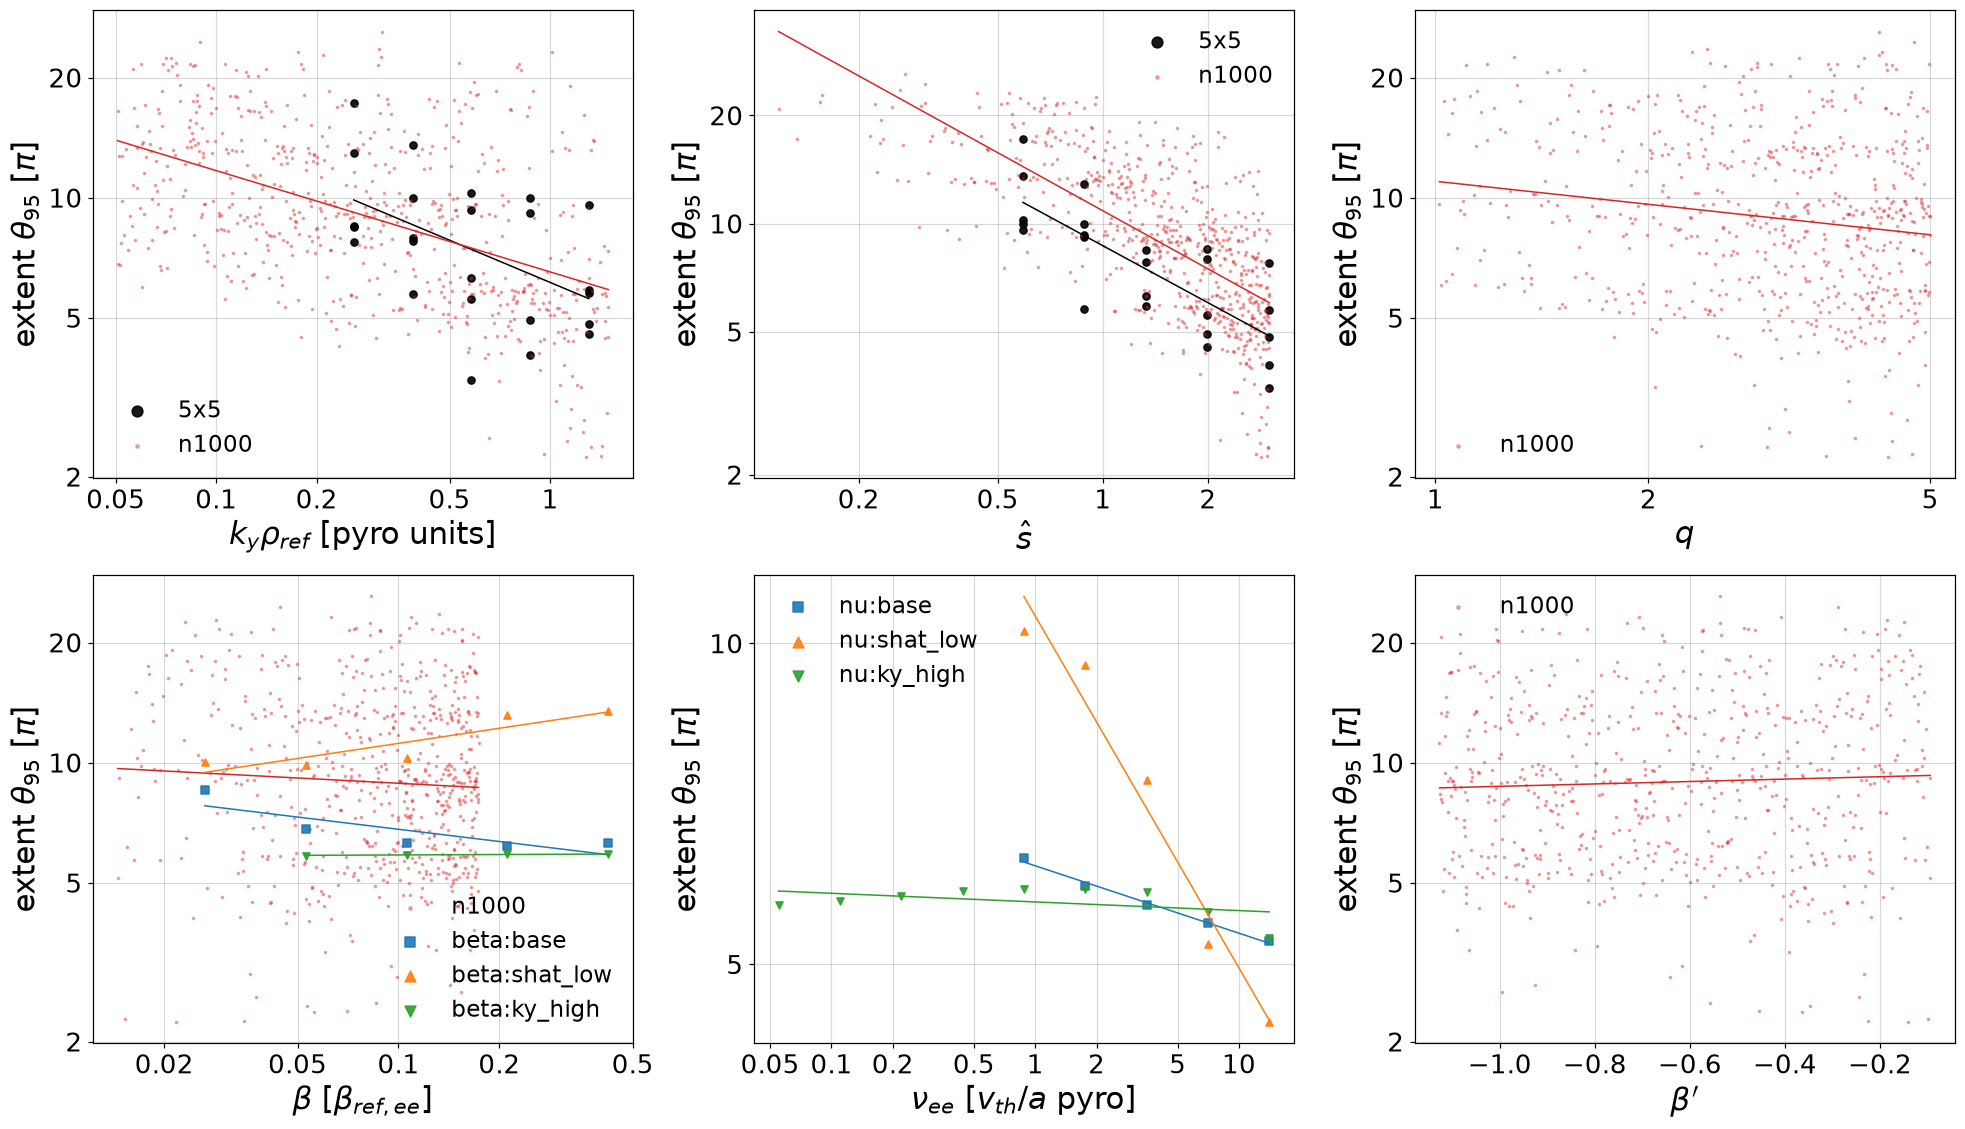

In [6]:
labels = dict(ky="$k_y\\rho_{ref}$ [pyro units]", shat="$\\hat{s}$", q="$q$", beta="$\\beta$ [$\\beta_{ref,ee}$]", nu_e="$\\nu_{ee}$ [$v_{th}/a$ pyro]",
              aLTe="$a/L_{Te}$", aLTi="$a/L_{Ti}$", aLne="$a/L_{ne}$", aLni="$a/L_{ni}$", kappa="$\\kappa$", delta="$\\delta$",
              s_kappa="$s_\\kappa$", s_delta="$s_\\delta$", shift="$d R_0/dr$", beta_prime="$\\beta'$", nperiod="nperiod")
colour = {"5x5": "k", "n1000": "C3", "nu:base": "C0", "nu:shat_low": "C1", "nu:ky_high": "C2", "beta:base": "C0", "beta:shat_low": "C1", "beta:ky_high": "C2"}
mark = {"5x5": "o", "n1000": ".", "nu:base": "s", "nu:shat_low": "^", "nu:ky_high": "v", "beta:base": "s", "beta:shat_low": "^", "beta:ky_high": "v"}

def panel(ax, n, yfun=None):
    lines = []
    back = (lambda v: np.exp(v)) if is_log(n) else (lambda v: v)   # fit variable -> axis value
    for k, g in groups.items():
        if not varies(g, n): continue
        x = tx(n, g[n].values)
        y = np.log(g.extent.values) if yfun is None else yfun(k, g)
        f = ols(y, x); xs = np.linspace(x.min(), x.max(), 50)
        out = np.exp if yfun is None else (lambda v: v)              # extent panels are log-y, residual panels linear
        ax.plot(back(xs), out(f["b"][0] + f["b"][1] * xs), c=colour[k], lw=1, marker="")
        txt = f"{k}: {f['b'][1]:+.3f}±{f['ci'][1]:.3f} (n={f['n']})"
        ax.scatter(back(x), out(y), s=8 if k == "n1000" else 22, c=colour[k], marker=mark[k], alpha=0.35 if k == "n1000" else 0.9, label=k)
        print(n, txt); lines.append(txt); res[(n, k)] = (f["b"][1], f["ci"][1], f["n"])
    if is_log(n): ax.set_xscale("log")
    ax.set_xlabel(labels[n]); ax.legend(loc="best", markerscale=1.5)
    return lines

res = {}
fig, axs = plt.subplots(int(np.ceil(len(params) / 3)), 3, figsize=(18, 5.2 * np.ceil(len(params) / 3)), squeeze=False)
for ax, n in zip(axs.flat, params):
    panel(ax, n); ax.set_yscale("log"); ax.set_ylabel("extent $\\theta_{95}$ [$\\pi$]"); plain_ticks(ax)
for ax in axs.flat[len(params):]: ax.axis("off")
fig.tight_layout(); fig.savefig(plot_dir / "fig1_extent_vs_each_parameter.png")
marginal = dict(res)

## Figure 2. Partial residuals: is there anything left after kᵧ^a ŝ^b?

Residual of ln(extent) after removing the joint kᵧ–ŝ law, against each *other* parameter. Flat (slope consistent with 0) means no dependence. n1000: the law is fitted on n1000's own kᵧ and ŝ (two parameters, same form as the law). Ladders: the 5×5 refit above (kᵧ, ŝ are fixed along a ladder, so a law cannot be fitted there). Each group's residual is centred on its own mean, so only the slope is shown.

q n1000: -0.331±0.041 (n=654)
beta n1000: +0.000±0.032 (n=654)
beta beta:base: -0.102±0.125 (n=5)
beta beta:shat_low: +0.126±0.115 (n=5)
beta beta:ky_high: +0.004±0.006 (n=4)
nu_e nu:base: -0.063±0.011 (n=5)
nu_e nu:shat_low: -0.330±0.119 (n=5)
nu_e nu:ky_high: -0.008±0.014 (n=9)
beta_prime n1000: -0.028±0.065 (n=654)


n1000 own k_y-shat fit (n=654): a = -0.253±0.021, b = -0.536±0.031, R2 0.723


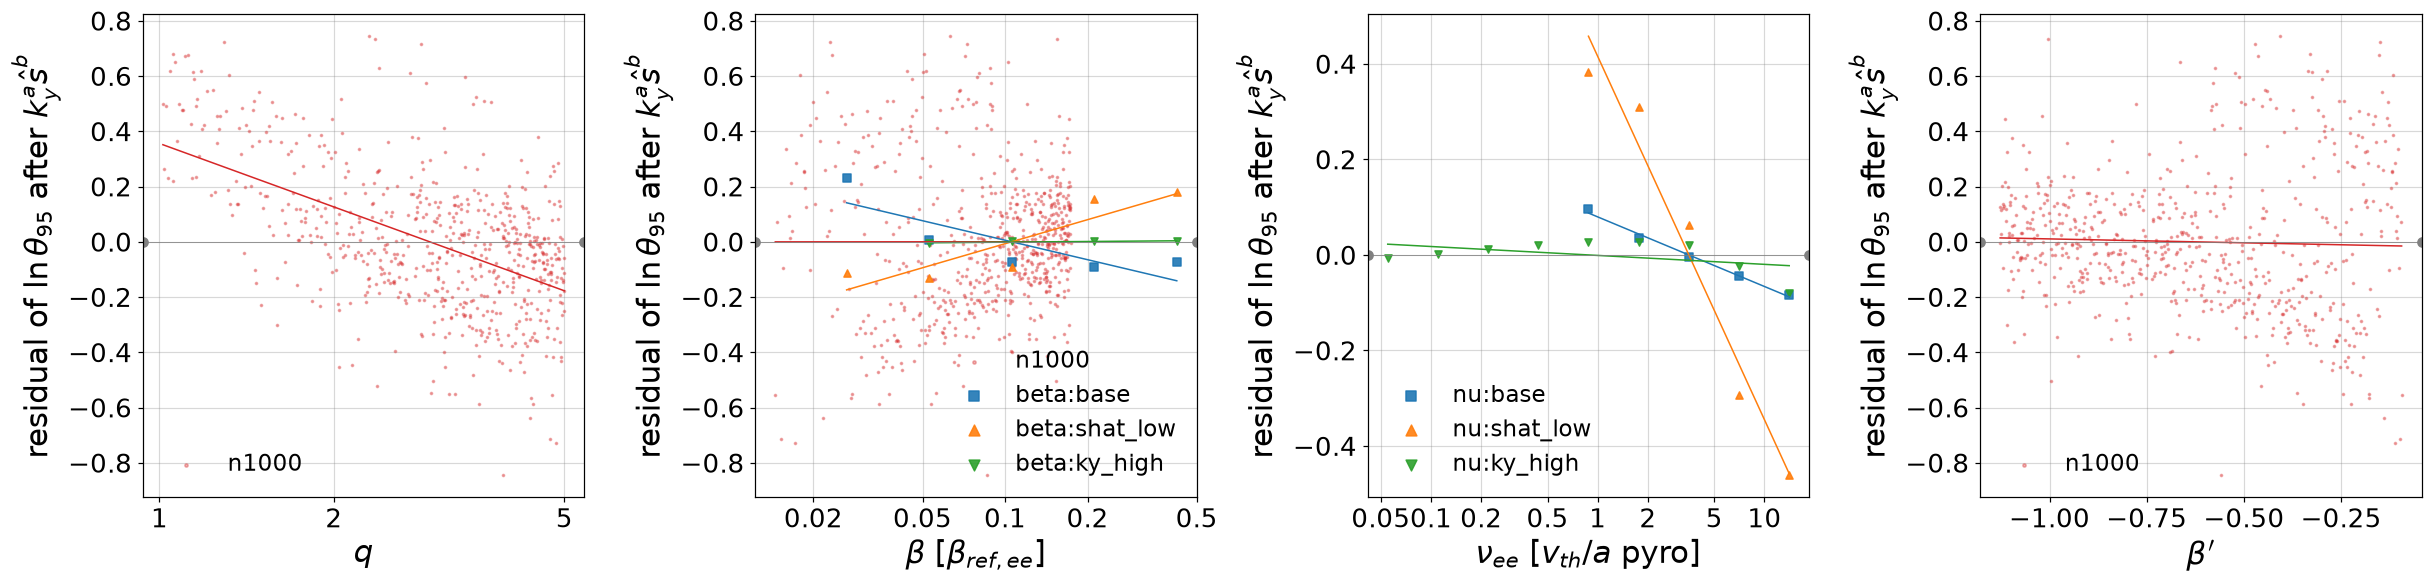

In [7]:
def resid(k, g):
    if k == "n1000":
        f = ols(y_of(g), np.column_stack([tx("ky", g.ky), tx("shat", g.shat)])); a, b = f["b"][1], f["b"][2]
        global n1000_law; n1000_law = f
    else:
        a, b = a_law, b_law
    r = y_of(g) - a * tx("ky", g.ky) - b * tx("shat", g.shat)
    return r - r.mean()

others = [n for n in params if n not in ("ky", "shat")]
res = {}
fig, axs = plt.subplots(1, len(others), figsize=(5.6 * len(others), 5.4), squeeze=False)
for ax, n in zip(axs.flat, others):
    panel(ax, n, yfun=resid); ax.axhline(0, c="grey", lw=0.5); ax.set_ylabel("residual of $\\ln\\theta_{95}$ after $k_y^a\\hat s^b$"); plain_ticks(ax)
fig.tight_layout(); fig.savefig(plot_dir / "fig2_partial_residuals.png")
partial = dict(res)
print(f"n1000 own k_y-shat fit (n={n1000_law['n']}): a = {n1000_law['b'][1]:+.3f}±{n1000_law['ci'][1]:.3f}, b = {n1000_law['b'][2]:+.3f}±{n1000_law['ci'][2]:.3f}, R2 {n1000_law['r2']:.3f}")

## Figure 3. Multi-parameter regression

`ln extent` on the tested parameters (log, or linear where a parameter is not positive), per database. **n1000**: every parameter that varies there. **KX_SCAN pooled**: the 5×5 grid plus all ladder rungs, which is the only place ν varies (with kᵧ, ŝ, β). Collinear columns (|r| > 0.999, e.g. β′ ∝ β in the LHC deck) are dropped and named. `ΔR²` and `ΔAIC` are drop-one: R² lost and AIC *gained* (positive = the parameter helps) when that parameter alone is removed.

n1000 LHC n=654
 parameter  exponent   ci95    dR2     dAIC
        ky   -0.2741 0.0177 0.2772 578.5720
      shat   -0.5542 0.0264 0.5074 838.7342
         q   -0.3406 0.0412 0.0789 221.2120
      beta   -0.0714 0.0964 0.0006   0.1298
beta_prime   -0.2078 0.1946 0.0013   2.4227 
R2 = 0.8061

KX_SCAN pooled (5x5 + ladders) n=51
parameter  exponent   ci95    dR2    dAIC
       ky   -0.3168 0.1012 0.2287 29.7462
     shat   -0.4521 0.1065 0.4207 46.5024
     beta    0.0161 0.1061 0.0005 -1.8967
     nu_e   -0.1117 0.0516 0.1092 15.6035 
R2 = 0.7352



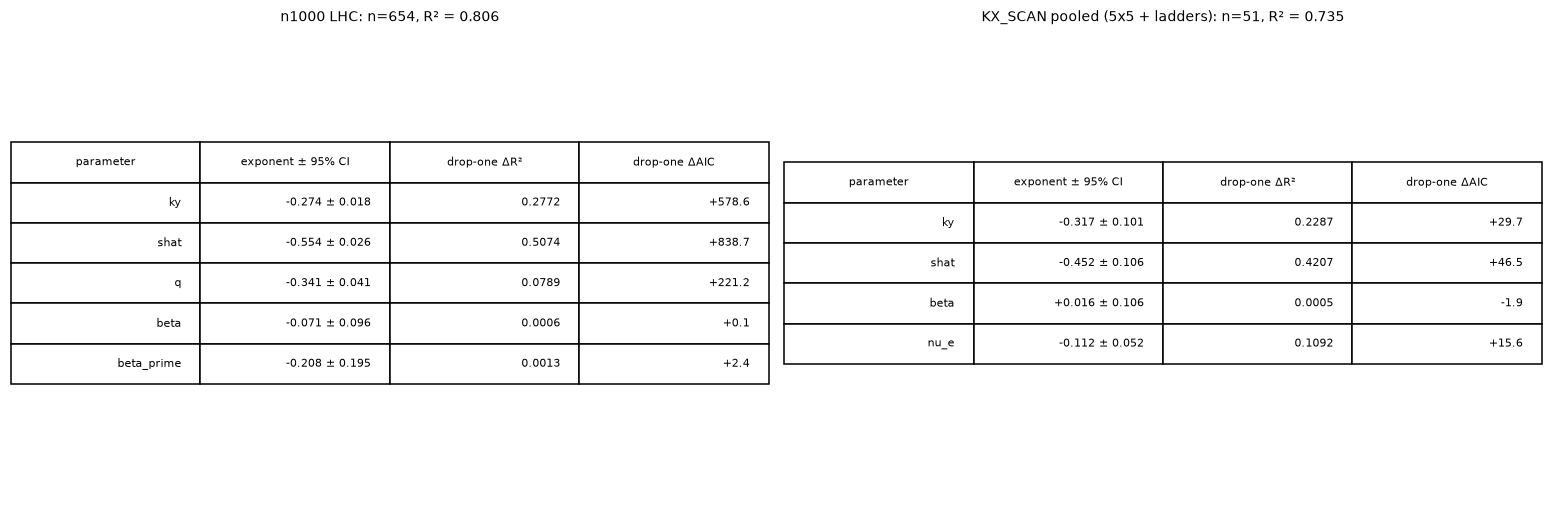

In [8]:
def regress(g, cand):
    cols = []
    for n in cand:
        if not varies(g, n): continue
        x = tx(n, g[n].values)
        if any(abs(np.corrcoef(x, c)[0, 1]) > 0.999 for _, c in cols):
            print(f"  dropped collinear: {n}"); continue
        cols.append((n, x))
    ns = [n for n, _ in cols]; y = y_of(g)
    full = ols(y, np.column_stack([c for _, c in cols]))
    out = []
    for j, n in enumerate(ns):
        sub = ols(y, np.column_stack([c for m, (_, c) in enumerate(cols) if m != j]))
        out.append(dict(parameter=n, exponent=full["b"][j + 1], ci95=full["ci"][j + 1], dR2=full["r2"] - sub["r2"], dAIC=sub["aic"] - full["aic"]))
    return pd.DataFrame(out), full

pooled = pd.concat([good[good.db == "5x5"], good[good.db.str.contains(":")]])
tables = {}
for title, g in (("n1000 LHC", groups["n1000"]), ("KX_SCAN pooled (5x5 + ladders)", pooled)):
    print(title, f"n={len(g)}")
    tables[title], full = regress(g, params)
    tables[title].attrs.update(r2=full["r2"], n=full["n"])
    print(tables[title].round(4).to_string(index=False), f"\nR2 = {full['r2']:.4f}\n")
fig, axs = plt.subplots(1, 2, figsize=(14, 0.5 * max(len(t) for t in tables.values()) + 2))
for ax, (title, t) in zip(axs, tables.items()):
    ax.axis("off"); ax.set_title(f"{title}: n={t.attrs['n']}, R² = {t.attrs['r2']:.3f}", fontsize=9)
    cell = [[r.parameter, f"{r.exponent:+.3f} ± {r.ci95:.3f}", f"{r.dR2:.4f}", f"{r.dAIC:+.1f}"] for r in t.itertuples()]
    ax.table(cellText=cell, colLabels=["parameter", "exponent ± 95% CI", "drop-one ΔR²", "drop-one ΔAIC"], loc="center").scale(1, 1.8)
fig.savefig(plot_dir / "fig3_regression_table.png")

## Figure 4. n1000: measured against the law's prediction

The law as used for GFTM sizing is the **envelope** `9.46 kᵧ^−0.351 ŝ^−0.527`, which is the least-squares centre × 1.327. y = x is the envelope, the lower dashed line is the centre (÷1.327). The 1.327 margin was set on 24 cells of the 5×5; n1000 is out of sample for it (different q, β, ν-fixed-at-its-own-deck, 1000 kᵧ–ŝ points).

n1000 (n=654): measured/envelope median 0.726, p5-p95 0.481-1.201; 86.2% at or below the envelope, 29.4% between centre and envelope, 13.8% above it


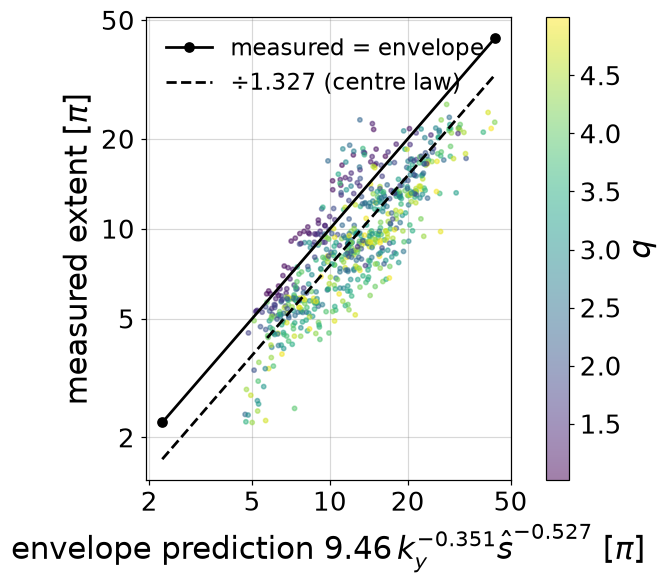

In [9]:
g = groups["n1000"]
pred = law_published["envelope"] * g.ky ** law_published["a"] * g.shat ** law_published["b"]
ratio = g.extent / pred
fig, ax = plt.subplots(figsize=(5.5, 5.2))
ax.scatter(pred, g.extent, s=8, alpha=0.5, c=g.q, cmap="viridis"); ax.set_xscale("log"); ax.set_yscale("log")
lim = np.array([min(pred.min(), g.extent.min()), max(pred.max(), g.extent.max())])
ax.plot(lim, lim, "k", label="measured = envelope"); ax.plot(lim, lim / law_published["margin"], "k--", label=f"÷{law_published['margin']} (centre law)")
plain_ticks(ax); ax.set_xlabel("envelope prediction $9.46\\,k_y^{-0.351}\\hat s^{-0.527}$ [$\\pi$]"); ax.set_ylabel("measured extent [$\\pi$]"); ax.legend()
fig.colorbar(ax.collections[0], label="$q$"); fig.savefig(plot_dir / "fig4_n1000_measured_vs_law.png")
below = float((ratio <= 1).mean()); within = float(((ratio <= 1) & (ratio >= 1 / law_published["margin"])).mean())
print(f"n1000 (n={len(g)}): measured/envelope median {ratio.median():.3f}, p5-p95 {ratio.quantile(.05):.3f}-{ratio.quantile(.95):.3f}; "
      f"{100 * below:.1f}% at or below the envelope, {100 * within:.1f}% between centre and envelope, {100 * (ratio > 1).mean():.1f}% above it")

## Verdict, parameter by parameter

**Depends**: the 95 % interval of the partial-residual slope excludes 0. **Does not depend (within the fit)**: the interval contains 0, and the interval is quoted. The effect is the change of the extent across the central 90 % of the sampled range (p5 → p95), from the slope. For kᵧ and ŝ the slope is the joint-law exponent.

In [10]:
def effect(n, slope, g):
    x = tx(n, g[n].values); lo, hi = np.percentile(x, [5, 95])
    return 100 * (np.exp(slope * (hi - lo)) - 1)

verdict = []
for (n, k), (s, ci, m) in partial.items():
    verdict.append(dict(parameter=n, database=k, slope=s, ci95=ci, n=m, verdict="DEPENDS" if abs(s) > ci else "no dependence found",
                        effect_p5_to_p95_pct=effect(n, s, groups[k])))
verdict = pd.DataFrame(verdict)
print(verdict.round(4).to_string(index=False))
for n in names:
    if n not in params and n != "nu_i": print(f"{n}: constant in every database; cannot be tested")
print(f"\njoint k_y-s_hat exponents: 5x5 refit a={a_law:+.3f}±{law['ci'][1]:.3f} b={b_law:+.3f}±{law['ci'][2]:.3f}; published -0.351/-0.527; "
      f"n1000 own fit a={n1000_law['b'][1]:+.3f}±{n1000_law['ci'][1]:.3f} b={n1000_law['b'][2]:+.3f}±{n1000_law['ci'][2]:.3f}")
for i, name, pub in ((1, "a", law_published["a"]), (2, "b", law_published["b"])):
    d = n1000_law["b"][i] - pub; print(f"  n1000 {name} - published = {d:+.3f} ({d / (n1000_law['ci'][i] / 1.96):+.1f} sigma of n1000's own error)")
json.dump(dict(counts=counts.to_dict("records"), law_5x5=dict(a=a_law, b=b_law, ci=law["ci"][1:].tolist(), n=law["n"]),
               n1000_law=dict(a=n1000_law["b"][1], b=n1000_law["b"][2], ci=n1000_law["ci"][1:].tolist(), n=n1000_law["n"]),
               verdict=verdict.to_dict("records"), regression={k: t.to_dict("records") for k, t in tables.items()},
               n1000_vs_envelope=dict(n=len(g), below=below, within=within, median_ratio=float(ratio.median()))),
          open(plot_dir / "summary.json", "w"), indent=1, default=float)

 parameter      database   slope   ci95   n             verdict  effect_p5_to_p95_pct
         q         n1000 -0.3313 0.0406 654             DEPENDS              -35.4137
      beta         n1000  0.0002 0.0322 654 no dependence found                0.0293
      beta     beta:base -0.1018 0.1246   5 no dependence found              -22.4303
      beta beta:shat_low  0.1256 0.1152   5             DEPENDS               36.8098
      beta  beta:ky_high  0.0035 0.0061   4 no dependence found                0.6580
      nu_e       nu:base -0.0633 0.0114   5             DEPENDS              -14.6040
      nu_e   nu:shat_low -0.3303 0.1189   5             DEPENDS              -56.1386
      nu_e    nu:ky_high -0.0081 0.0143   9 no dependence found               -3.9681
beta_prime         n1000 -0.0283 0.0652 654 no dependence found               -2.5894
aLTe: constant in every database; cannot be tested
aLTi: constant in every database; cannot be tested
aLne: constant in every database; cann

## Sensitivity: n1000 under the tearing-parity gate instead of the consensus label

The same joint fit and partial residual, with the 5×5/ladder MTM gate (E > 0.5, ω < 0) on n1000, to show the verdicts do not hinge on which MTM definition is used.

In [11]:
alt = df[(df.db == "n1000") & df.tear & unstable & (df.edge < gate_edge)]
print(f"n1000, tearing-parity gate: n={len(alt)} (label-MTM gate: n={len(groups['n1000'])}; overlap {len(set(alt.run) & set(groups['n1000'].run))})")
f2 = ols(np.log(alt.extent.values), np.column_stack([np.log(alt.ky), np.log(alt.shat)]))
print(f"  joint fit a = {f2['b'][1]:+.3f}±{f2['ci'][1]:.3f}, b = {f2['b'][2]:+.3f}±{f2['ci'][2]:.3f}, R2 {f2['r2']:.3f}")
r_alt = np.log(alt.extent.values) - f2["b"][1] * np.log(alt.ky) - f2["b"][2] * np.log(alt.shat)
for n in ("q", "beta"):
    f = ols(r_alt.values, tx(n, alt[n].values)); print(f"  partial residual vs {n}: slope {f['b'][1]:+.3f}±{f['ci'][1]:.3f}")
t_alt, f_alt = regress(alt, params); print(t_alt.round(4).to_string(index=False), f"R2 = {f_alt['r2']:.3f}")

n1000, tearing-parity gate: n=680 (label-MTM gate: n=654; overlap 654)
  joint fit a = -0.252±0.021, b = -0.538±0.030, R2 0.727
  partial residual vs q: slope -0.325±0.040
  partial residual vs beta: slope +0.002±0.032


 parameter  exponent   ci95    dR2     dAIC
        ky   -0.2721 0.0177 0.2631 579.2310
      shat   -0.5609 0.0252 0.5535 913.3171
         q   -0.3354 0.0411 0.0743 217.6524
      beta   -0.0727 0.0966 0.0006   0.1991
beta_prime   -0.2169 0.1942 0.0014   2.8371 R2 = 0.805


In [12]:
# MTM-only: how many 5x5 / ladder cells are MTM under the user's rule, and the 5x5 law on them
cmp = df.groupby("db", sort=False).apply(lambda g: __import__("pandas").Series(dict(
    loaded=len(g), fallback_tear=int(g.tear.sum()), label_MTM=int((g.label == "MTM").sum()),
    both=int(((g.label == "MTM") & g.tear).sum()), label_only=int(((g.label == "MTM") & ~g.tear).sum()),
    tear_only=int((~(g.label == "MTM") & g.tear).sum()),
    MTM_unstable_gate=int(((g.label == "MTM") & (g.gamma > gate_gamma) & (g.edge < gate_edge)).sum()))), include_groups=False)
print(cmp.to_string())
n1 = df[df.db == "n1000"]
print(f"n1000: {len(n1)} loaded, label MTM {int((n1.label == 'MTM').sum())}, removed {len(n1) - int((n1.label == 'MTM').sum())}; "
      f"kept after gamma>0 and box gate {len(groups['n1000'])}")
g5m = df[(df.db == "5x5") & (df.label == "MTM") & (df.gamma > gate_gamma) & (df.edge < gate_edge)]
f5 = ols(np.log(g5m.extent.values), np.column_stack([np.log(g5m.ky), np.log(g5m.shat)]))
print(f"5x5 law on label-MTM cells only (n={f5['n']} vs {law['n']} in the fallback fit): a = {f5['b'][1]:+.3f}±{f5['ci'][1]:.3f}, "
      f"b = {f5['b'][2]:+.3f}±{f5['ci'][2]:.3f}; fallback fit a={a_law:+.3f}, b={b_law:+.3f}")

               loaded  fallback_tear  label_MTM  both  label_only  tear_only  MTM_unstable_gate
db                                                                                             
5x5                25             24         22    22           0          2                 22
n1000            1000            790        757   757           0         33                654
nu:base             8              4          4     4           0          0                  4
nu:shat_low         8              4          4     4           0          0                  4
nu:ky_high          8              8          8     8           0          0                  8
beta:base           4              4          3     3           0          1                  3
beta:shat_low       4              4          2     2           0          2                  2
beta:ky_high        4              4          4     4           0          0                  3
n1000: 1000 loaded, label MTM 757, remov